In [1]:
# Librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargamos el archivo sin encabezados

df_mkt = pd.read_csv("Analisis GAC Full7agosto 2026(Marketing).csv",header=None)

df_mkt.head()

,0,1,2,3,4,5,6,7,8,9,...,46,47,48,49,50,51,52,53,54,55
0,Marketing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Leads total,543,178,416,422,967,954,1409,1315,1973,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Ventas X Mes,12,7,8,13,6,21,17,17,23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Nombres que tendrán las columnas

columnas = ["Mes","Inicio","Fin","Dias","Modelo","Color","Numero de Leads","Leads por Dia","Ranking"]

In [4]:
# Extraemos la tabla de Plaza Angelópolis

angelopolis = df_mkt.iloc[23:82, 0:9].copy()
angelopolis.columns = columnas
angelopolis["Plaza"] = "Angelópolis"


# Extraemos la tabla de Plaza Tlaxcala

tlaxcala = df_mkt.iloc[88:118, 0:9].copy()
tlaxcala.columns = columnas
tlaxcala["Plaza"] = "Tlaxcala"


# Extraemos la tabla de Plaza Pachuca

pachuca = df_mkt.iloc[122:136, 0:9].copy()
pachuca.columns = columnas
pachuca["Plaza"] = "Pachuca"

In [5]:
# Unimos las campañas de las tres plazas

df = pd.concat([angelopolis, tlaxcala, pachuca],ignore_index=True)

df.head()

,Mes,Inicio,Fin,Dias,Modelo,Color,Numero de Leads,Leads por Dia,Ranking,Plaza
0,Abril,4/4/2025,4/9/2025,6,GS8 HEV,Negro,55,9,15,Angelópolis
1,NaN,4/10/2025,4/13/2025,4,GS8,Blanco,10,3,26,Angelópolis
2,NaN,4/14/2025,4/24/2025,11,Emzoom,Azul laguna,147,13,5,Angelópolis
3,NaN,4/25/2025,5/7/2025,13,GS4,Gris,93,7,19,Angelópolis
4,Mayo,5/8/2025,5/19/2025,12,Emzoom R,Azul laguna,78,7,22,Angelópolis


In [6]:
# Rellenamos los nombres de los meses faltantes

df["Mes"] = df.groupby("Plaza")["Mes"].ffill()

df.head()

,Mes,Inicio,Fin,Dias,Modelo,Color,Numero de Leads,Leads por Dia,Ranking,Plaza
0,Abril,4/4/2025,4/9/2025,6,GS8 HEV,Negro,55,9,15,Angelópolis
1,Abril,4/10/2025,4/13/2025,4,GS8,Blanco,10,3,26,Angelópolis
2,Abril,4/14/2025,4/24/2025,11,Emzoom,Azul laguna,147,13,5,Angelópolis
3,Abril,4/25/2025,5/7/2025,13,GS4,Gris,93,7,19,Angelópolis
4,Mayo,5/8/2025,5/19/2025,12,Emzoom R,Azul laguna,78,7,22,Angelópolis


In [7]:
# Columnas que deben convertirse a tipo numérico

columnas_numericas = ["Dias","Numero de Leads","Leads por Dia","Ranking"]


# Convertimos las columnas a numéricas

for columna in columnas_numericas:
    df[columna] = (
        df[columna]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.strip())

    df[columna] = pd.to_numeric(
        df[columna],
        errors="coerce")

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Mes              103 non-null    str    
 1   Inicio           103 non-null    str    
 2   Fin              100 non-null    str    
 3   Dias             100 non-null    float64
 4   Modelo           102 non-null    str    
 5   Color            102 non-null    str    
 6   Numero de Leads  87 non-null     float64
 7   Leads por Dia    85 non-null     float64
 8   Ranking          83 non-null     float64
 9   Plaza            103 non-null    str    
dtypes: float64(4), str(6)
memory usage: 8.2 KB


In [9]:
df.isnull().sum()

Mes                 0
Inicio              0
Fin                 3
Dias                3
Modelo              1
Color               1
Numero de Leads    16
Leads por Dia      18
Ranking            20
Plaza               0
dtype: int64

In [10]:
# Eliminamos las campañas sin días o sin número de leads

df = df.dropna(subset=["Dias", "Numero de Leads"])


# Reiniciamos el índice

df = df.reset_index(drop=True)

df.shape

(87, 10)

In [11]:
# Número de campañas disponibles por plaza

df["Plaza"].value_counts()

Plaza
Angelópolis    52
Tlaxcala       25
Pachuca        10
Name: count, dtype: int64

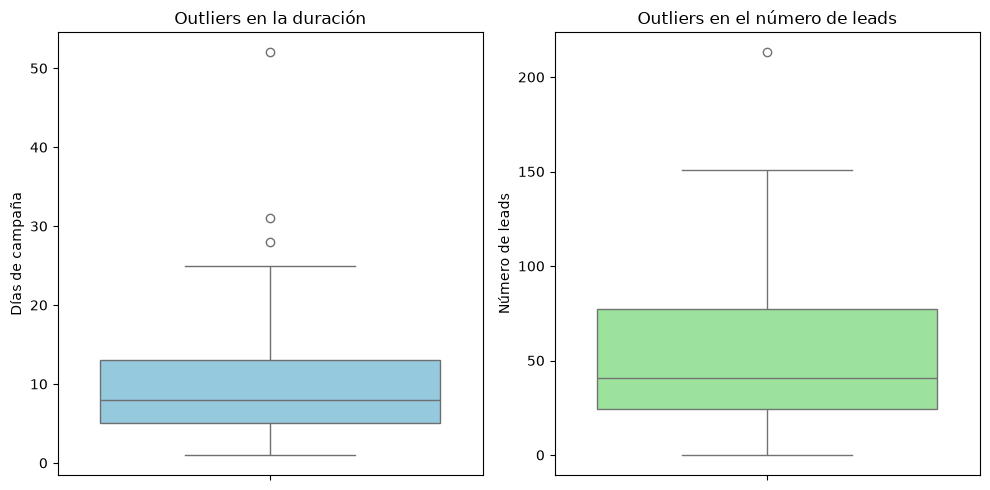

In [12]:
# Diagramas de caja de las variables del modelo

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df["Dias"],color="skyblue")

plt.title("Outliers en la duración")
plt.ylabel("Días de campaña")


plt.subplot(1, 2, 2)

sns.boxplot(y=df["Numero de Leads"],color="lightgreen")

plt.title("Outliers en el número de leads")
plt.ylabel("Número de leads")

plt.tight_layout()
plt.show()

In [13]:
# Función para detectar outliers

def detectar_outliers(dataframe, columna):

    Q1 = dataframe[columna].quantile(0.25)
    Q3 = dataframe[columna].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = dataframe[
        (dataframe[columna] < limite_inferior) |
        (dataframe[columna] > limite_superior)]

    print("Variable:", columna)
    print("Límite inferior:", limite_inferior)
    print("Límite superior:", limite_superior)

    return outliers[
        ["Plaza","Inicio","Fin","Dias","Numero de Leads"]]

In [14]:
# Outliers de la duración

detectar_outliers(df, "Dias")

Variable: Dias
Límite inferior: -7.0
Límite superior: 25.0


,Plaza,Inicio,Fin,Dias,Numero de Leads
53,Tlaxcala,5/10/2025,6/9/2025,31.0,130.0
61,Tlaxcala,8/13/2025,9/9/2025,28.0,32.0
80,Pachuca,2/7/2026,3/30/2026,52.0,139.0


In [15]:
# Outliers del número de leads

detectar_outliers(df, "Numero de Leads")

Variable: Numero de Leads
Límite inferior: -54.25
Límite superior: 155.75


,Plaza,Inicio,Fin,Dias,Numero de Leads
13,Angelópolis,7/8/2025,7/27/2025,20.0,213.0


In [16]:
# Variables numéricas que analizaremos

variables_marketing = ["Dias","Numero de Leads","Leads por Dia","Ranking"]


# Matriz de correlación

Corr_Factors = df[variables_marketing].corr()

Corr_Factors

,Dias,Numero de Leads,Leads por Dia,Ranking
Dias,1.000000,0.509535,-0.341629,-0.082808
Numero de Leads,0.509535,1.000000,0.451122,-0.216341
Leads por Dia,-0.341629,0.451122,1.000000,-0.311890
Ranking,-0.082808,-0.216341,-0.311890,1.000000


In [17]:
# Valor absoluto de las correlaciones

Corr_Factors1 = abs(Corr_Factors)

Corr_Factors1

,Dias,Numero de Leads,Leads por Dia,Ranking
Dias,1.000000,0.509535,0.341629,0.082808
Numero de Leads,0.509535,1.000000,0.451122,0.216341
Leads por Dia,0.341629,0.451122,1.000000,0.311890
Ranking,0.082808,0.216341,0.311890,1.000000


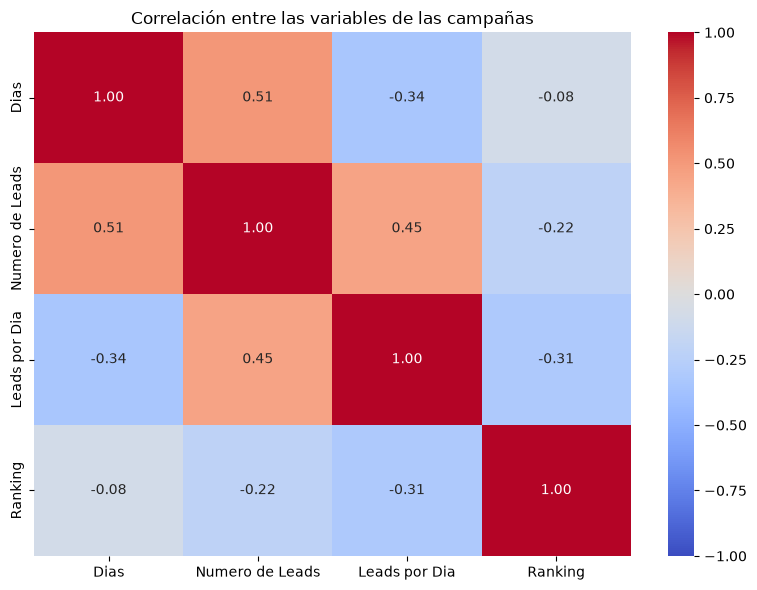

In [18]:
# Heatmap de las correlaciones

plt.figure(figsize=(8, 6))
sns.heatmap(Corr_Factors,cmap="coolwarm",annot=True,fmt=".2f",vmin=-1,vmax=1)

plt.title("Correlación entre las variables de las campañas")
plt.tight_layout()
plt.show()

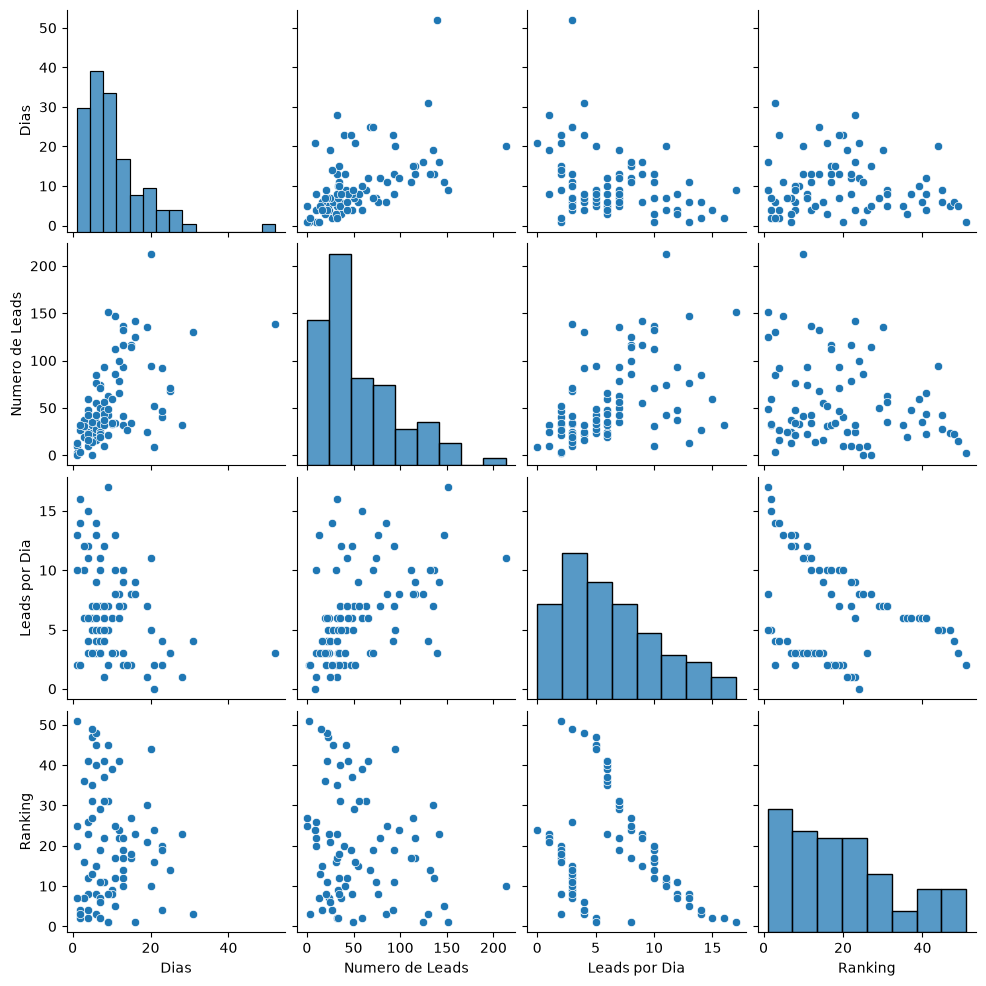

In [19]:
# Graficamos las relaciones entre las variables numéricas

sns.pairplot(df[variables_marketing])

plt.show()

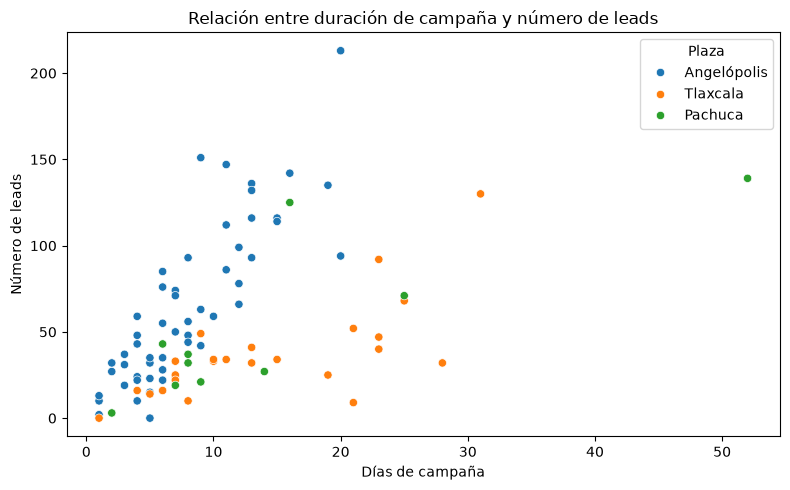

In [20]:
# Relación entre la duración y el número de leads

plt.figure(figsize=(8, 5))
sns.scatterplot(x="Dias",y="Numero de Leads",hue="Plaza",data=df)

plt.title("Relación entre duración de campaña y número de leads")
plt.xlabel("Días de campaña")
plt.ylabel("Número de leads")
plt.legend(title="Plaza")

plt.tight_layout()
plt.show()

In [21]:
# Variable independiente: duración de la campaña

Vars_Indep = df[["Dias"]]


# Variable dependiente: número de leads

Var_Dep = df["Numero de Leads"]

In [22]:
# Importamos y creamos el modelo

from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [23]:
# Ajustamos el modelo

model.fit(X=Vars_Indep,y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[2.75]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Dias']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,26.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [24]:
# Intercepto

model.intercept_

np.float64(26.899342561547655)

In [25]:
# Coeficiente de Días

model.coef_

array([2.74616597])

**Ecuación: Número de leads = 26.899342561547655 + 2.74616597(Días)**


---

In [26]:
# Coeficiente de determinación

coef_Deter = model.score(X=Vars_Indep,y=Var_Dep)

coef_Deter

0.25962571996501993

In [27]:
# Coeficiente de correlación

coef_Correl = df["Dias"].corr(df["Numero de Leads"])

coef_Correl

np.float64(0.5095348074126245)

In [28]:
# Predicciones 

Predicciones = model.predict(X=Vars_Indep)

Predicciones

array([ 43.37633837,  37.88400643,  57.10716821,  62.59950015,
        59.85333418,  37.88400643,  46.12250434,  62.59950015,
        43.37633837,  51.61483628,  32.3916745 ,  37.88400643,
        37.88400643,  81.82266193,  35.13784047,  68.09183209,
        62.59950015,  40.6301724 ,  70.83799805,  46.12250434,
        51.61483628,  35.13784047,  43.37633837,  68.09183209,
        54.36100224,  40.6301724 ,  48.86867031,  43.37633837,
        51.61483628,  46.12250434,  40.6301724 ,  79.07649596,
        29.64550853,  43.37633837,  29.64550853,  43.37633837,
        32.3916745 ,  35.13784047,  59.85333418,  48.86867031,
        48.86867031,  40.6301724 ,  62.59950015,  48.86867031,
        40.6301724 ,  57.10716821,  57.10716821,  81.82266193,
        37.88400643,  59.85333418,  29.64550853,  37.88400643,
        57.10716821, 112.03048758,  46.12250434,  90.06115983,
        29.64550853,  54.36100224,  46.12250434,  54.36100224,
        43.37633837, 103.79198967,  90.06115983,  48.86

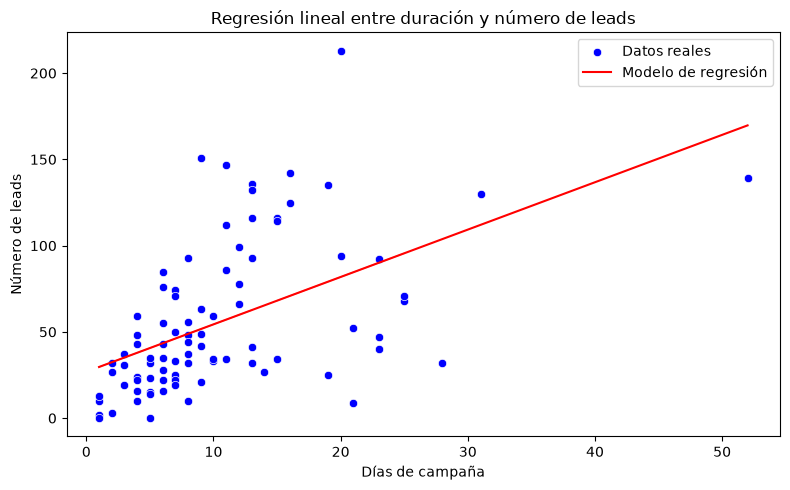

In [29]:
# Gráfica del modelo de regresión lineal

plt.figure(figsize=(8, 5))
sns.scatterplot(x="Dias",y="Numero de Leads",data=df,color="blue",label="Datos reales")

sns.lineplot(x=df["Dias"],y=Predicciones,color="red",label="Modelo de regresión")

plt.title("Regresión lineal entre duración y número de leads")
plt.xlabel("Días de campaña")
plt.ylabel("Número de leads")
plt.legend()

plt.tight_layout()
plt.show()